# My Optimizers

В этом домашнем задании вам предстоит реализовать своими руками оптимизаторы.

Часть кода оптимизаторов уже реализована - есть подсказки в `__init__` и определен метод `step`. По сути, вам остается только заполнить недостающие части, например, по алгоритму из документации pytorch: [SGD](https://pytorch.org/docs/stable/generated/torch.optim.SGD.html), [Adam](https://pytorch.org/docs/stable/generated/torch.optim.Adam.html)

PS. Кода там совсем немного. В эталонном решении 2 класса оптимизаторов поместились на 60 строчек. Основное -- это разобраться в формулах и перенести их в код.


#### 🤔 Что если тесты не проходят?

Скорее всего, у вас где-то ошибка. Тк торчовые реаоизации оптимизаторов точно работают корректно.

Для дебага рекомендую добавить принтов, залогировать значения лосса, градиентов.
Перепроверить по шагам каждую формулу из доки торча отдельно.

Возможно добавить дебаг в код тестов - изучите их код. В тестах проверяется, что значения параметров модели оптимизированной вашим и торчовым оптимизатором совпадает после нескольких шагов оптимизации для рандомных входных данных.

Если есть подозрение, что в тестах есть ошибка, загрузите ноутбук на колаб, сделайте ссылку, чтобы поделиться ноутбуком и скиньте мне с описанием, где ошибка, почему и возможно, вы можете сразу предложить исправление этой ошибки?)

Или на самом деле, можете сразу присылать пулл-реквест в [репозиторий, где хранятся тесты](https://github.com/fintech-dl-hse/checkhw/tree/main/tests/optimization))



#### ❗ Hint

**Torch/Numpy**
В `pytorch` очень много методов называются аналогично numpy. В том числе есть
`torch.rand_like`, `torch.zeros_like`, `torch.ones_like` методы. Возможно, некоторые из этих методов могут вам потребоваться при решении текущей домашки.

**Важно!** Обратите, пожалуйста, внимание, что во время шага оптимизации нельзя делать шаг обновления на самих тензорах. Надо работать напрямую с данными тензора (см первый сем)

```python
for param in model.parameters():
    param.data = param.data - learning_rate * param.grad
```



#### 🙈 Доп задание



В конце ноутбука есть опциональная часть задания. Эта часть не влияет на оценку, но желательна к исполнению, чтобы закрепить материал. Приступайте к опциональной части дз только после того, как убедились, что все тесты проходят и вы получили баллы за обязательную часть дз.





## Обязательная часть ДЗ:

In [25]:
import torch
import torch.nn as nn
# Другие импорты нельзя добавлять. Убирать тоже нельзя. Эта ячейка будет
# копироваться в отдельный файл во время проверки домашки.


class MySGD():
    # Конструктор класса: вызывается при создании ЭКЗЕМЛЯРА класса MySGD(...)
    def __init__(self, parameteres_generator, lr=0.001):
        super().__init__()  # Вызываем конструктор родителя (в данном случае не обязателен, но хорошо для стиля)

        # Сохраняем список параметров модели (веса и смещения)
        # parameteres_generator — это генератор, например, model.parameters()
        # Преобразуем его в список, чтобы можно было проходить по нему много раз
        self.model_params = list(parameteres_generator)

        # Сохраняем скорость обучения (learning rate)
        self.learning_rate = lr

        return  # Явный return не обязателен, но допустим

    def step(self): # ЦЕЛЬ: Реализовать метод step() в классе MySGD, который будет обновлять веса модели по правилу градиентного спуска
        """
        Выполняет один шаг оптимизации: обновляет все параметры модели (веса, смещения и т.д.)
        в направлении, противоположном градиенту.
        """
        # Проходим по каждому параметру модели (веса, смещения и т.д.)
        for param in self.model_params:
            # Проверяем, есть ли у параметра градиент (иногда grad=None)
            if param.grad is not None:
                # param.data — это данные тензора (без графа вычислений)
                # param.grad — это градиент, вычисленный через loss.backward()
                # Формула: param = param - learning_rate * grad
                # Но мы не можем писать `param = ...`, потому что это создаст новый тензор,
                # а не изменит существующий. Поэтому используем `.data` и операцию `-=`:
                param.data -= self.learning_rate * param.grad.data

        return  # Завершаем метод

#--------------------------------------------------------------------------------------

class MyAdam():
    def __init__(self, parameteres_generator, lr=0.001, betas=(0.9, 0.999), eps=1e-08):
        super().__init__()  # Вызываем конструктор родителя (для совместимости, хотя не обязателен)

        # Сохраняем список параметров модели (веса, смещения и т.д.)
        # Преобразуем генератор в список, чтобы можно было обращаться к элементам по индексу
        self.model_params = list(parameteres_generator)

        # Сохраняем гиперпараметры
        self.learning_rate = lr
        self.beta_moment_1 = betas[0]  # beta1 для первого момента (momentum)
        self.beta_moment_2 = betas[1]  # beta2 для второго момента (RMSprop)
        self.eps = eps                 # Малое число для численной стабильности

        # Счётчик шагов оптимизации (начинается с 0, увеличивается в step())
        self.step_counter = 0

        # Создаём списки для хранения первого и второго моментов градиентов
        # Для каждого параметра нужен тензор ТОЙ ЖЕ формы, что и сам параметр,
        # но заполненный нулями (начальное состояние моментов = 0)
        # torch.zeros_like(param) создаёт тензор такой же формы, как param, но с нулями
        self.parameters_moment_1 = [torch.zeros_like(param) for param in self.model_params]
        self.parameters_moment_2 = [torch.zeros_like(param) for param in self.model_params]

        return  # Явный return не обязателен, но допустим

    def step(self):
        """
        Выполняет один шаг оптимизации Adam:
        1. Обновляет первый и второй моменты,
        2. Применяет bias correction,
        3. Обновляет параметры модели.
        """
        # Увеличиваем счётчик шагов на 1 (важно для bias correction!)
        self.step_counter += 1

        # Проходим по каждому параметру и его соответствующим моментам
        # Используем enumerate, чтобы получить индекс i
        for i, param in enumerate(self.model_params):
            # Проверяем, есть ли у параметра градиент (на случай, если он заморожен)
            if param.grad is not None:
                # Получаем текущий градиент (тензор той же формы, что и param)
                grad = param.grad.data

                # === ШАГ 1: обновляем первый момент (m_t) ===
                # m_t = beta1 * m_{t-1} + (1 - beta1) * g_t
                self.parameters_moment_1[i] = (
                    self.beta_moment_1 * self.parameters_moment_1[i] +
                    (1.0 - self.beta_moment_1) * grad
                )

                # === ШАГ 2: обновляем второй момент (v_t) ===
                # v_t = beta2 * v_{t-1} + (1 - beta2) * (g_t)^2
                # grad ** 2 — поэлементное возведение в квадрат
                self.parameters_moment_2[i] = (
                    self.beta_moment_2 * self.parameters_moment_2[i] +
                    (1.0 - self.beta_moment_2) * (grad ** 2)
                )

                # === ШАГ 3: bias correction ===
                # Так как моменты начинались с 0, они "смещены" в начале обучения.
                # Исправляем это делением на (1 - beta^t)
                bias_correction_1 = 1.0 - (self.beta_moment_1 ** self.step_counter)
                bias_correction_2 = 1.0 - (self.beta_moment_2 ** self.step_counter)

                # Исправленные моменты
                corrected_moment_1 = self.parameters_moment_1[i] / bias_correction_1
                corrected_moment_2 = self.parameters_moment_2[i] / bias_correction_2

                # === ШАГ 4: обновляем параметр ===
                # Формула: param = param - lr * (m_hat / (sqrt(v_hat) + eps))
                # Важно: работаем с .data, чтобы обновить тензор "на месте"
                param.data -= self.learning_rate * corrected_moment_1 / (
                    torch.sqrt(corrected_moment_2) + self.eps
                )

        return  # Завершаем метод

#### Tests

In [26]:
from tqdm.auto import tqdm
from torch.optim import SGD, Adam
import copy


# initialize a model
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.sequential = nn.Sequential(
            nn.Linear(784, 2048),
            nn.ReLU(),
            nn.Linear(2048, 100),
            nn.ReLU(),
            nn.Linear(100, 10)
        )
        return

    def forward(self, x_coordinates):
        # x_coordinates ~ [ batch_size, 2 ]
        scores = self.sequential(x_coordinates)   # [ batch_size, 10 ]
        return scores

def _optimizer_step(model, model_state, optimizer_class, optimizer_params, model_inputs_batches, target_labels_batches, criterion):
    model.load_state_dict(model_state)
    optimizer = optimizer_class(model.parameters(), **optimizer_params)

    for model_inputs, target_labels in zip(model_inputs_batches, target_labels_batches):
        model.zero_grad()

        prediction = model.forward(model_inputs)
        loss = criterion(prediction, target_labels)
        # print("loss", loss.item())
        loss.backward()
        optimizer.step()

        # print("list(model.parameters())", list(model.parameters()))

    return copy.deepcopy(list(model.parameters()))


def _test_my_optimizer(torch_optimizer, my_optimizer, optimizer_params,
                       model='linear',
                       batch_size = 3, num_batches = 10,
                       name=None,
                       ):

    if model == 'linear':
        model = nn.Linear(784, 10)
    else:
        model = MLP()

    model_state = copy.deepcopy(model.state_dict())

    criterion = nn.CrossEntropyLoss()

    model_inputs =  [torch.rand([batch_size, 784]) for _ in range(num_batches)]
    target_labels = [torch.randint(0, 10, [batch_size]) for _ in range(num_batches)]

    torch_updated_params = _optimizer_step(model, model_state, torch_optimizer, optimizer_params, model_inputs, target_labels, criterion)
    my_updated_params    = _optimizer_step(model, model_state, my_optimizer,    optimizer_params, model_inputs, target_labels, criterion)

    for torch_updated_param, my_updated_param in tqdm(zip(torch_updated_params, my_updated_params), total=len(torch_updated_params), desc=name):
        # print(torch_updated_param)
        # print(my_updated_param)
        assert torch.allclose(torch_updated_param, my_updated_param, rtol=0.5, atol=1e-3), 'updated parameters are not equal'

def test_my_sgd():
    optimizer_params = {
        "lr": 0.01
    }
    torch_optimizer = SGD
    my_optimizer = MySGD

    _test_my_optimizer(torch_optimizer, my_optimizer, optimizer_params, name="Test SGD Linear")
    _test_my_optimizer(torch_optimizer, my_optimizer, optimizer_params, model='mlp', name="Test SGD MLP")


def test_my_adam():
    optimizer_params = {
        "lr": 0.01
    }
    torch_optimizer = Adam
    my_optimizer = MyAdam

    _test_my_optimizer(torch_optimizer, my_optimizer, optimizer_params, name="Test Adam Linear")
    _test_my_optimizer(torch_optimizer, my_optimizer, optimizer_params, model='mlp', name="Test Adam MLP")


test_my_sgd()
test_my_adam()

print("Tests are OK!")

Test SGD Linear:   0%|          | 0/2 [00:00<?, ?it/s]

Test SGD MLP:   0%|          | 0/6 [00:00<?, ?it/s]

Test Adam Linear:   0%|          | 0/2 [00:00<?, ?it/s]

Test Adam MLP:   0%|          | 0/6 [00:00<?, ?it/s]

Tests are OK!


# Свой train loop со своим оптимизатором

Если тесты проходят, можете обучить модель с помощью своего оптимизатора, например на задаче `FashionMNIST`.  Сравните свою реализацию с реализацией из `pytorch`.

**Важно** Эта часть ДЗ желательна, чтобы закрепить знания. Но не обязательно - проверяться не будет.

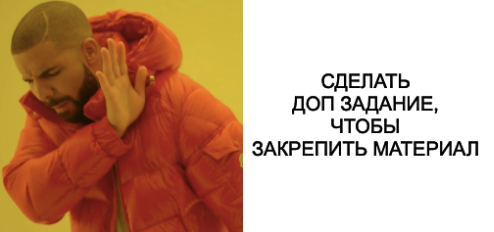

In [11]:
import torch #фреймворк для глубокого обучения. Всё, что связано с тензорами, автоматическим дифференцированием и нейросетями, находится здесь.
import torch.nn as nn # содержит классы для построения нейронных сетей: слои (Linear, Conv2d), функции потерь (CrossEntropyLoss), регуляризацию (Dropout) и т.д.
import torch.nn.functional as F #содержит функции активации (relu, softmax), потери и другие операции, которые не требуют создания объекта (в отличие от nn.ReLU()).
from torchvision.datasets import FashionMNIST
import numpy as np
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [19]:
class VectorSet(): #Определяем новый класс VectorSet, который будет преобразовывать изображения в векторы и нормализовать их.
    def __init__(self, train=True): # Конструктор класса. Принимает флаг train: если True — загружаем обучающую часть, иначе — тестовую.
        self.data = FashionMNIST("./fashion_mnist", train=train, download=True)

    def __len__(self): #Метод, который говорит, сколько примеров в датасете. Нужен для DataLoader.
        return len(self.data)

    def __getitem__(self, item): #Метод, который вызывается, когда мы пишем dataset[i]. Возвращает i-й пример.
        sample, label = self.data[item] #Получаем из исходного датасета изображение (sample — объект PIL) и метку (label — целое число от 0 до 9).
        sample = np.array(sample, dtype=np.float32).reshape(-1) / 255
#Преобразуем изображение:
#np.array(sample) — конвертируем PIL-изображение в массив NumPy,
#dtype=np.float32 — задаём тип данных (PyTorch предпочитает float32),
#.reshape(-1) — "вытягиваем" матрицу 28×28 в вектор длиной 784,
#/ 255 — нормализуем пиксели в диапазон [0, 1] (вместо [0, 255]).
        return dict( #Возвращаем словарь с ключами 'sample' и 'label' — удобно для последующей обработки в DataLoader
            sample=sample,
            label=label,
        )

vs = VectorSet()

In [20]:
# Определяем простую полносвязную нейронную сеть для задачи классификации на FashionMNIST
class SimpleNet(nn.Module):
    def __init__(self, input_size=784, hidden_size=128, num_classes=10):
        # Вызываем конструктор родительского класса nn.Module — обязательно для корректной работы PyTorch
        super().__init__()
        # Первый полносвязный слой: преобразует входной вектор (784 пикселя) в скрытое представление (128 нейронов)
        self.fc1 = nn.Linear(input_size, hidden_size)
        # Второй полносвязный слой: преобразует скрытое представление в логиты для 10 классов (выход без активации)
        self.fc2 = nn.Linear(hidden_size, num_classes)
        # Слой Dropout с вероятностью 0.2: во время обучения случайно зануляет 20% активаций для предотвращения переобучения
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        # Прямой проход: данные последовательно проходят через слои сети
        # Сначала применяем первый линейный слой, затем нелинейную функцию активации ReLU (вводит нелинейность, без которой сеть = линейная модель)
        x = F.relu(self.fc1(x))
        # Применяем Dropout — работает только в режиме обучения (model.train()), во время оценки (model.eval()) отключается автоматически
        x = self.dropout(x)
        # Применяем второй линейный слой — получаем логиты (сырые предсказания) для каждого из 10 классов
        # Softmax НЕ применяется, потому что функция потерь CrossEntropyLoss сама вычисляет softmax внутри для численной стабильности
        x = self.fc2(x)
        # Возвращаем логиты — их будет использовать функция потерь (например, CrossEntropyLoss)
        return x

In [21]:
# Функция для обучения одной модели с заданным оптимизатором и возврата истории потерь
def train_model(optimizer_class, model, train_loader, criterion, num_epochs=2, **opt_kwargs):
    """
    Обучает модель с заданным оптимизатором.

    Args:
        optimizer_class: класс оптимизатора (MySGD, MyAdam или torch.optim.SGD и т.д.)
        model: нейросеть (экземпляр nn.Module)
        train_loader: загрузчик обучающих данных (DataLoader)
        criterion: функция потерь (например, CrossEntropyLoss)
        num_epochs: количество проходов по всему датасету
        opt_kwargs: именованные аргументы для оптимизатора (например, lr=0.001, betas=(0.9, 0.999))

    Returns:
        losses: список значений функции потерь по каждому батчу (для построения графика)
    """
    # Создаём экземпляр оптимизатора, передавая ему все обучаемые параметры модели и гиперпараметры (через **opt_kwargs)
    optimizer = optimizer_class(model.parameters(), **opt_kwargs)

    losses = []  # Инициализируем пустой список для хранения значений потерь после каждого батча

    # Цикл по эпохам: одна эпоха = один полный проход по всему обучающему датасету
    for epoch in range(num_epochs):
        # Цикл по батчам: DataLoader автоматически разбивает данные на пачки (например, по 64 изображения)
        for batch in train_loader:
            # Извлекаем признаки (изображения в виде векторов) и метки (целые числа от 0 до 9) из словаря, возвращаемого VectorSet
            x = batch['sample']      # форма: [batch_size, 784] — нормализованные пиксели
            y = batch['label']       # форма: [batch_size] — истинные классы

            # Убеждаемся, что данные являются тензорами PyTorch (на случай, если DataLoader вернул NumPy-массивы)
            if not isinstance(x, torch.Tensor):
                x = torch.tensor(x)  # Преобразуем в тензор, если это не так
            if not isinstance(y, torch.Tensor):
                y = torch.tensor(y)

            # ВАЖНО: обнуляем градиенты всех параметров модели перед новым шагом
            # Без этого градиенты будут накапливаться от предыдущих батчей, и обучение сломается
            # Так как у твоих оптимизаторов (MySGD, MyAdam) нет метода zero_grad(), делаем это вручную
            for param in model.parameters():
                if param.grad is not None:  # Проверяем, есть ли градиент (на случай замороженных параметров)
                    param.grad.zero_()      # Обнуляем градиент "на месте" (in-place операция)

            # Прямой проход (forward pass): передаём входные данные через модель и получаем предсказания (логиты)
            outputs = model(x)
            # Вычисляем значение функции потерь: сравниваем логиты с истинными метками
            loss = criterion(outputs, y)

            # Обратный проход (backward pass): вычисляем градиенты потери по всем параметрам модели
            # Результат сохраняется в атрибуте .grad каждого параметра
            loss.backward()

            # Шаг оптимизации: обновляем веса модели в направлении, противоположном градиенту
            # Используется либо твой реализованный оптимизатор (MySGD/MyAdam), либо официальный из PyTorch
            optimizer.step()

            # Сохраняем скалярное значение потери для текущего батча (используем .item() для преобразования тензора в число Python)
            losses.append(loss.item())

    # Возвращаем список всех значений потерь — он будет использован для построения графика сходимости
    return losses

In [22]:
# Подготовка данных для обучения модели

# Создаём экземпляр обучающего датасета на основе класса VectorSet
# Параметр train=True указывает, что нужно загрузить именно обучающую часть FashionMNIST (60 000 изображений)
train_dataset = VectorSet(train=True)

# Создаём загрузчик данных (DataLoader), который будет:
# - разбивать датасет на батчи по 64 изображения (batch_size=64),
# - перемешивать примеры перед каждой эпохой (shuffle=True) — это улучшает сходимость SGD,
# - автоматически преобразовывать данные в тензоры и ускорять загрузку через фоновые процессы
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# Определяем функцию потерь для задачи многоклассовой классификации
# CrossEntropyLoss объединяет в себе:
#   - применение softmax к логитам (для получения вероятностей),
#   - вычисление логарифмической потери между предсказанными вероятностями и истинными метками
# Она ожидает на вход:
#   - логиты формы [N, C] (N — размер батча, C — число классов),
#   - целочисленные метки формы [N] со значениями от 0 до C-1
criterion = nn.CrossEntropyLoss()

In [23]:
# Запуск сравнения: обучаем модели с использованием твоих и официальных оптимизаторов

# Устанавливаем общие гиперпараметры для честного сравнения:
num_epochs = 2   # количество эпох обучения (мало, чтобы быстро проверить корректность)
lr = 0.001       # скорость обучения (learning rate) — одинаковая для всех оптимизаторов

# Сравнение SGD: обучаем модель с твоей реализацией MySGD
print("Обучаем с MySGD...")
model1 = SimpleNet()  # создаём новую модель (свежая инициализация весов)
losses_my_sgd = train_model(MySGD, model1, train_loader, criterion, num_epochs, lr=lr)

# Сравнение SGD: обучаем модель с официальной реализацией torch.optim.SGD
print("Обучаем с torch.optim.SGD...")
model2 = SimpleNet()  # создаём новую модель (веса инициализируются заново — важно для честного сравнения!)
losses_torch_sgd = train_model(torch.optim.SGD, model2, train_loader, criterion, num_epochs, lr=lr)

# Сравнение Adam: обучаем модель с твоей реализацией MyAdam
print("Обучаем с MyAdam...")
model3 = SimpleNet()  # новая модель — чтобы не было влияния от предыдущего обучения
losses_my_adam = train_model(MyAdam, model3, train_loader, criterion, num_epochs, lr=lr)

# Сравнение Adam: обучаем модель с официальной реализацией torch.optim.Adam
print("Обучаем с torch.optim.Adam...")
model4 = SimpleNet()  # ещё одна новая модель — каждая модель обучается независимо
losses_torch_adam = train_model(torch.optim.Adam, model4, train_loader, criterion, num_epochs, lr=lr)

Обучаем с MySGD...
Обучаем с torch.optim.SGD...
Обучаем с MyAdam...
Обучаем с torch.optim.Adam...


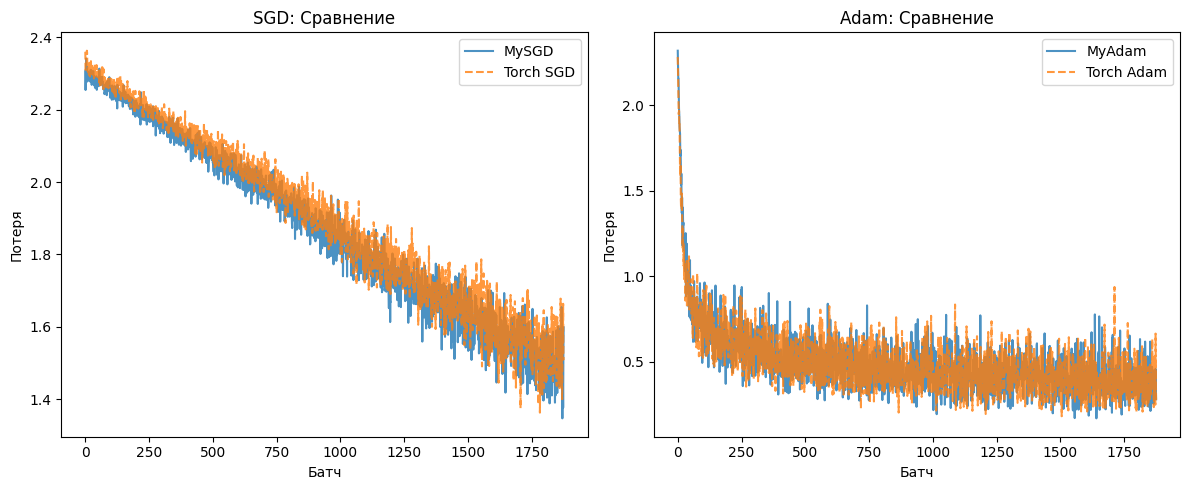

In [24]:
#визуал
plt.figure(figsize=(12, 5))

# SGD
plt.subplot(1, 2, 1)
plt.plot(losses_my_sgd, label='MySGD', alpha=0.8)
plt.plot(losses_torch_sgd, label='Torch SGD', linestyle='--', alpha=0.8)
plt.title('SGD: Сравнение')
plt.xlabel('Батч')
plt.ylabel('Потеря')
plt.legend()

# Adam
plt.subplot(1, 2, 2)
plt.plot(losses_my_adam, label='MyAdam', alpha=0.8)
plt.plot(losses_torch_adam, label='Torch Adam', linestyle='--', alpha=0.8)
plt.title('Adam: Сравнение')
plt.xlabel('Батч')
plt.ylabel('Потеря')
plt.legend()

plt.tight_layout()
plt.show()